In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
import math
import keyring
import itertools
from ast import literal_eval

In [3]:
%%html
<style>
.rendered_html p {
    font-size: 12px;
    font-family: Times New Roman, serif;
    text-align:justify}
</style>

In [4]:
# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [5]:
# read in the data
# df = pd.read_csv(data_dir + "/data_processed/tbi_merged.csv")
df = pd.read_csv("../../data_processing/tbi_cleaned.csv")
df

C:\Users\yianz\AppData\Local\Temp\ipykernel_1924\2582001599.py:3: DtypeWarning: Columns (33,34,35,52,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data_processing/tbi_cleaned.csv")


,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451969,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,20.910320,20.910320,20.910320,32.363497
451970,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
451971,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
451972,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499


In [6]:
# # read path geopkg data
# car = gpd.read_file(data_dir + "/Data_Processed/car_trips.gpkg")
# bike = gpd.read_file(data_dir + "/Data_Processed/bike_trips.gpkg")
# transit = gpd.read_file(data_dir + "/Data_Processed/transit-trips.gpkg")
# walk = gpd.read_file(data_dir + "/Data_Processed/walk_trips.gpkg")

In [7]:
car = gpd.read_parquet("geodata/car.parquet")
bike = gpd.read_parquet("geodata/bike_lts.parquet")
transit = gpd.read_parquet('geodata/transit.parquet')
walk = gpd.read_parquet('geodata/walk.parquet')

In [8]:
bike_lts = gpd.read_feather("geodata/bike_lts.feather")

In [9]:
# preprocess bike

In [89]:
bike_lts
# weight = generalized cost
# distance x = distance on lts x
# wait for elevation

,trip_id,duration_seconds,distance_meters,weight,distance_meters_1,distance_meters_2,distance_meters_3,distance_meters_4,geometry
0,[1811206201001],21781.8,35771.3,14002.7,31340.529135,298.150005,3734.391881,397.351353,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
1,[1811206201002],21781.8,35771.3,14002.7,31340.529135,298.150005,3734.391881,397.351353,"LINESTRING (-92.91715 44.51007, -92.91576 44.5..."
2,[1811206203001],15218.0,25992.0,10165.6,24928.078483,298.150005,129.130877,636.653314,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
3,[1811206203002],15241.3,25997.8,10172.9,24933.897999,298.150005,129.130877,636.653314,"LINESTRING (-92.88609 44.73583, -92.88572 44.7..."
4,[1811206204001],13104.0,23178.3,8545.7,22358.880570,298.150005,85.485012,435.807499,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
...,...,...,...,...,...,...,...,...,...
458633,[2200279003003],6138.5,13541.8,2782.3,11780.143850,1689.470227,44.290975,27.871214,"LINESTRING (-93.14578 44.91527, -93.14603 44.9..."
458634,[2200279101001],8034.1,14334.2,4315.9,13878.443165,0.000000,225.336566,230.453257,"LINESTRING (-93.38229 45.04008, -93.38164 45.0..."
458635,[2200279101002],8034.1,14334.2,4315.9,13878.443165,0.000000,225.336566,230.453257,"LINESTRING (-93.35434 45.07169, -93.35359 45.0..."
458636,[2200279102001],4119.1,7267.8,2545.0,6976.301425,68.723028,7.893996,214.921328,"LINESTRING (-93.38229 45.04008, -93.38164 45.0..."


In [11]:
# preprocess transit

In [12]:
# some transit trips lack corresponding trip data
display(df[df["trip_id"] == '[1811541101009, 1811541101010, 1811541101011, 1811541101012]']["mode"]) # this trip is transit
display(transit[transit["trip_id"].str.contains("1811541101009")]) # can't find any transit trip containing the trip id

186    Transit
Name: mode, dtype: object

,trip_id,leg_index,start_time,end_time,origin_stop_id,origin_stop_name,destination_stop_id,destination_stop_name,route_id,route_short_name,route_long_name,route_type,leg_type,geometry


In [ ]:
# flag the missing transit trips
# re-validate this -- if < 5%, it is okay; if big, check it again
    # do some analysis on these missing trips-- there is likely some filtering/sanity checks

In [13]:
# calculate duration from star/tend times
transit["start_time_dt"] = pd.to_datetime(transit["start_time"])
transit["end_time_dt"] = pd.to_datetime(transit["end_time"])

transit["duration"] = (transit["end_time_dt"] - transit["start_time_dt"]).apply(lambda x: x.seconds / 60)

In [14]:
# create a gdf for linked trips
agg_fns = {
    "trip_id": "first",
    "leg_index": "count",
    "start_time": "first",
    "end_time": "last",
    "origin_stop_id": "first", # throw away
    "origin_stop_name": "first",
    "destination_stop_id": "first",
    "destination_stop_name": "first",
    "route_id": "first", 
    "route_short_name": "first",
    "route_long_name": "first",
    "route_type": "first", 
    "leg_type": "first", # end throw away
    "start_time_dt": "first",
    "end_time_dt": "last",
    "duration": "sum"
}

transit_grouped = transit.dissolve(by="trip_id", aggfunc=agg_fns) # merges geometries in addition to aggregating the rest of the columns

In [15]:
# currently ignore schools bus and taxi/ridehail/carshare -- can decide whether to omit or group with others later
# with school buses, we might need analysis for school-age children only since school buses aren't a widely available mode to the public, omit for now
# with taxi/ridehail/carshare, could be transit but it is very distinct,  omit for now
valid_modes = ["Car", "Bike/Scooter", "Walk", "Transit"]

In [16]:
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

### duration analysis

In [17]:
## overall summary statistics
df["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    451974.000000
mean         18.964511
std          21.713015
min           0.100000
25%           8.233333
50%          13.933333
75%          22.916667
95%          48.600000
max         970.516667
Name: duration, dtype: float64

(0.0, 200.0)

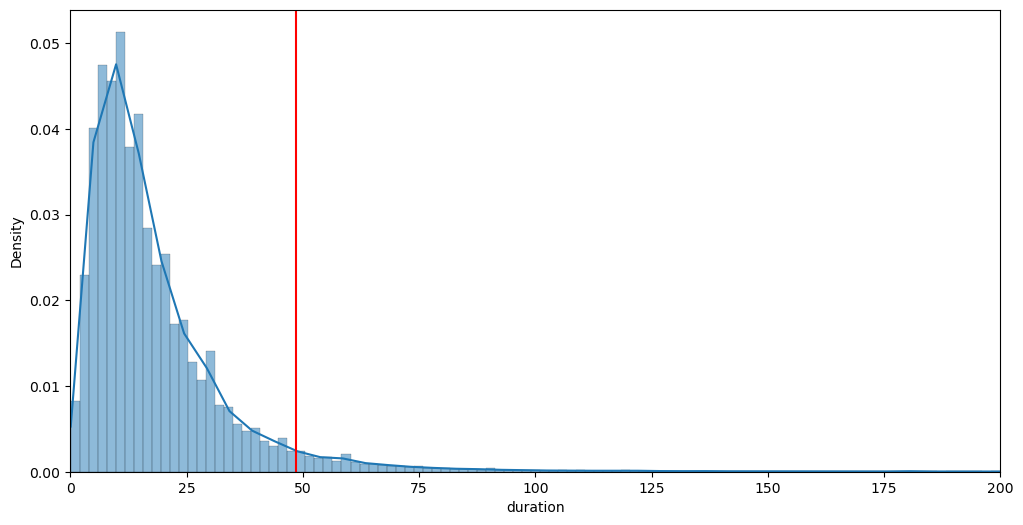

In [18]:
# overall distribution of duration
# there are repetitive peaks, likely since the temporal resolution is discrete with respect ot minutes
fig, ax = plot_density(df["duration"], bins=500)
ax.set_xlim(left=0, right=200) # cutoff upper end, there are some outliers that make the graph hard to read

Text(0.5, 0, 'log duration')

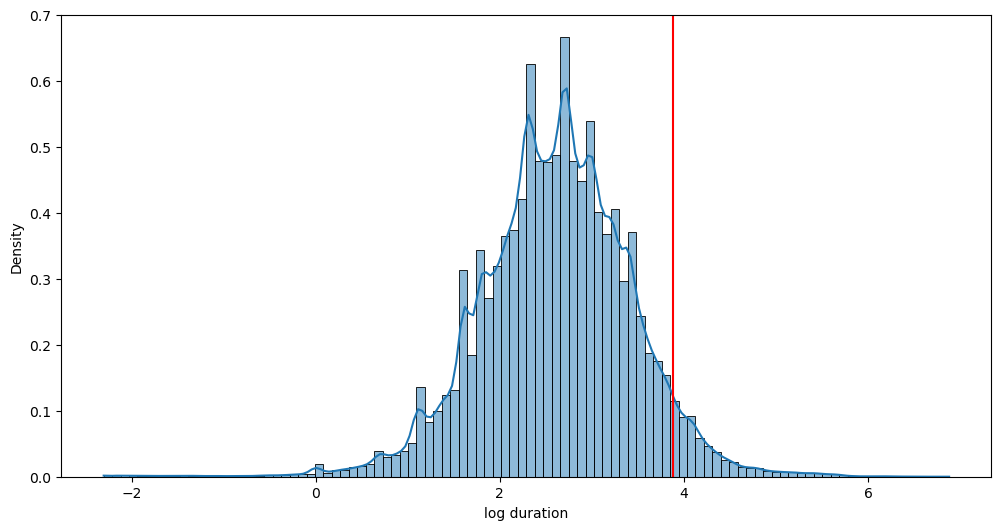

In [19]:
# overall distribution of the log of duration
fig, ax = plot_density(np.log(df["duration"]), bins=100)
ax.set_xlabel("log duration")

In [20]:
## duration analysis segmented by mode

In [22]:
def plot_mode_density(df: pd.DataFrame, key: str, percentile=0.95, size=(12, 6), bins=300, function=lambda x: x):
    palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
    fig, ax = plt.subplots(figsize=size)
    for mode in valid_modes: # cycle through all modes
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(function(group[key]), ax=ax, stat="density", kde=True, label=mode, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = function(group[key]).quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        plt.axvline(x=val, color=c) # plot line representing that value on the plot
    return fig, ax

In [23]:
def show_summaries(df: pd.DataFrame, key: str, percentile=0.95): # show normal summaries for each mode side by side
    res = []
    p = [0.25, 0.5, 0.75]
    p.append(percentile)
    for mode in valid_modes:
        group = df[df["mode"] == mode]
        res.append(group[key].describe(percentiles=p))
    x = pd.concat(res, axis=1)
    x.columns = valid_modes
    return x

In [24]:
show_summaries(df, "duration")

,Car,Bike/Scooter,Walk,Transit
count,377333.000000,7705.000000,50134.000000,11279.000000
mean,18.542229,23.640117,16.149813,38.154242
std,21.044895,25.802185,18.693085,29.783879
min,0.100000,0.133333,0.100000,0.133333
25%,8.333333,9.000000,6.433333,20.000000
50%,13.816667,16.083333,11.450000,32.033333
75%,22.350000,29.050000,19.466667,48.391667
95%,46.050000,66.286667,42.200000,85.260000
max,970.516667,325.800000,325.466667,570.000000


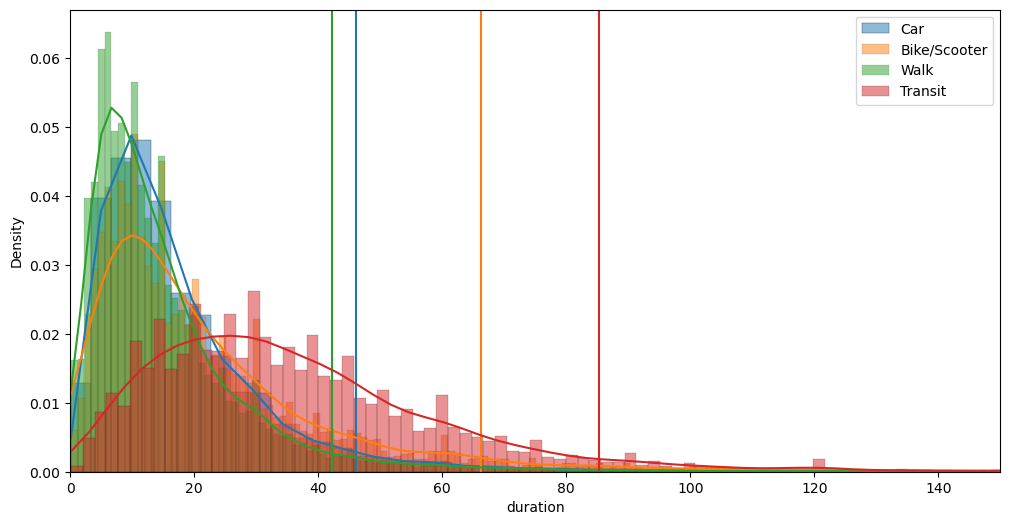

In [25]:
# plot of densities of all modes overlayed on top of one another
fig, ax = plot_mode_density(df, "duration")
ax.set_xlim(left=0, right=150)
plt.legend()

takeaways:

- durations tend to be right-skewed; people prefer shorter durations
- walk durations tend to be the shortest, followed by car, biking, and transit in that order
- there is small bias in durations as it is semi-categorical, with multiple peaks/non-continuous distribution
- the transit duration distribution deviates significantly from the other modes--transit riders are less sensitive to duration
- there remain some duration outliers

further analysis:
- trip duration as a percentage of the total trip time

### difference between driving and non-driving mode durations

In [26]:
# overall

difference_with_car_duration = df[(df["mode"] != "Car") & (df["mode"].isin(valid_modes))]["duration"] - \
    (car.set_index("trip_id").loc[df[(df["mode"] != "Car") & (df["mode"].isin(valid_modes))]["trip_id"].values].duration_seconds / 60).values

(-50.0, 150.0)

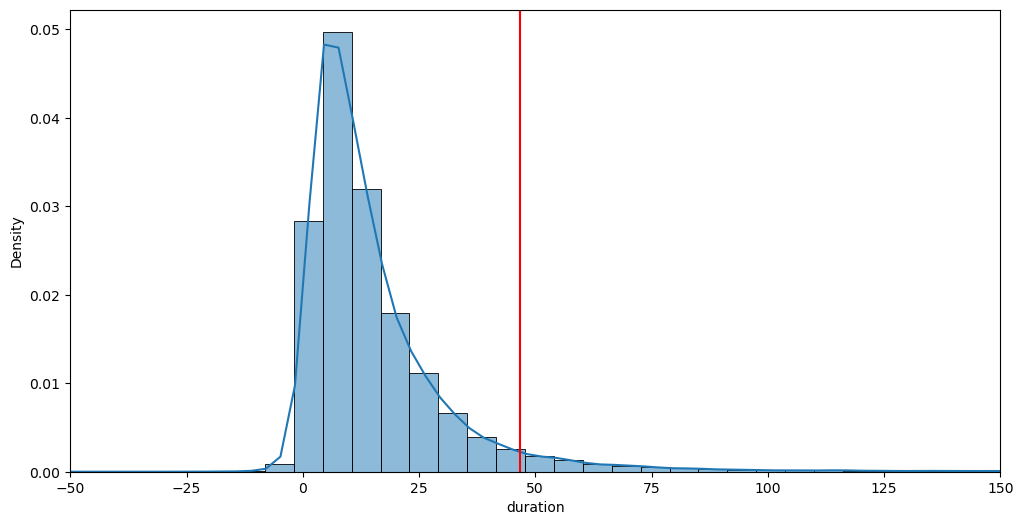

In [27]:
fig, ax = plot_density(difference_with_car_duration)
ax.set_xlim(left=-50, right=150)

In [28]:
difference_with_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    69118.000000
mean        16.152061
std         20.882794
min        -51.665000
25%          5.433333
50%         10.733333
75%         19.591250
95%         46.675250
max        570.000000
Name: duration, dtype: float64

In [29]:
# percent of all non-car trips that are faster than car
(difference_with_car_duration <= 0).sum() / len(difference_with_car_duration)

0.023597326311525217

In [30]:
# bike vs car

In [31]:
# for each bike trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these bikers tradeoff between car & bike duration
bike_minus_car_duration = df[df["mode"] == "Bike/Scooter"]["duration"] - (car.set_index("trip_id").loc[df[(df["mode"] == "Bike/Scooter")]["trip_id"].values].duration_seconds / 60).values

In [32]:
# not sure if it would be feasible to switch to bike if car is 53 minutes faster
# self sampling likely plays a role -- maybe adopt a smaller percentile to adjust?
bike_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    7705.000000
mean       16.805448
std        23.208526
min       -11.326667
25%         5.136667
50%        10.326667
75%        19.445000
95%        53.201667
max       303.550000
Name: duration, dtype: float64

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='duration', ylabel='Density'>)

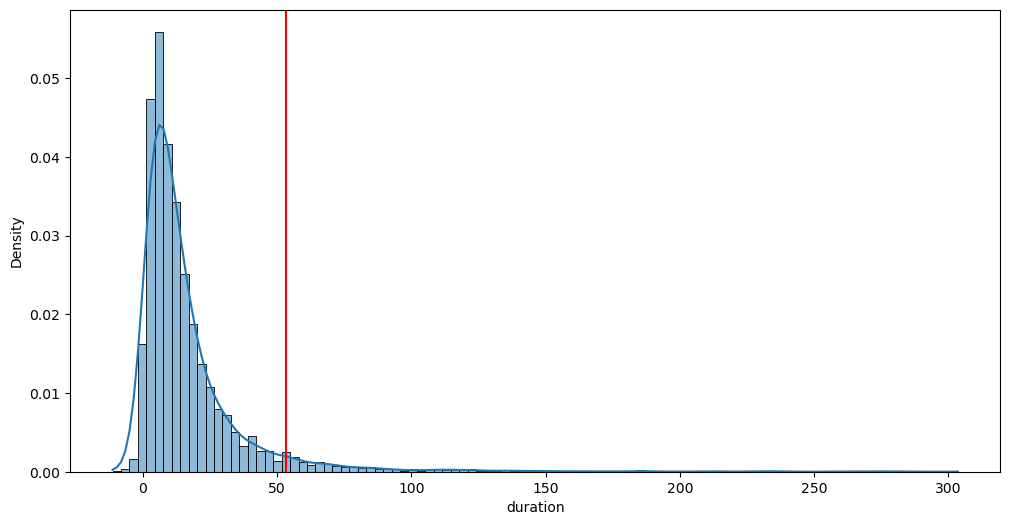

In [33]:
plot_density(bike_minus_car_duration)

In [34]:
# transit vs car

In [35]:
# for each transit trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these transit riders tradeoff between car & transit duration

transit_minus_car_duration = df[df["mode"] == "Transit"]["duration"] - \
    (car.set_index("trip_id").loc[df[(df["mode"] == "Transit")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 200.0)

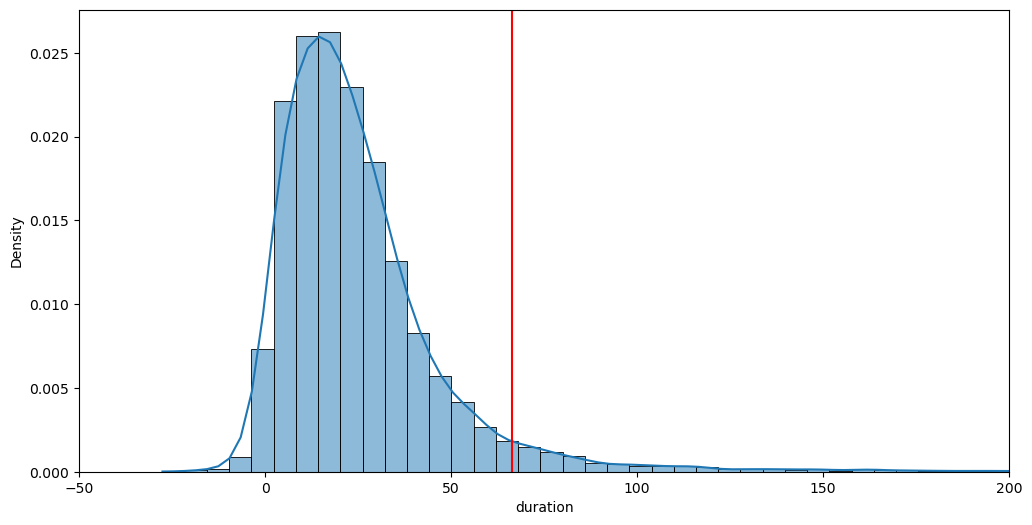

In [36]:
# positive means car duration < transit and vice versa
fig, ax = plot_density(transit_minus_car_duration)
ax.set_xlim(left=-50, right=200)

In [37]:
transit_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    11279.000000
mean        25.941877
std         26.901623
min        -27.603333
25%         10.948333
50%         20.401667
75%         32.680000
95%         66.365333
max        570.000000
Name: duration, dtype: float64

In [38]:
# walk vs car

In [39]:
# for each walk trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how walkers tradeoff between car & walk duration

walk_minus_car_duration = df[df["mode"] == "Walk"]["duration"] - \
    (car.set_index("trip_id").loc[df[(df["mode"] == "Walk")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 150.0)

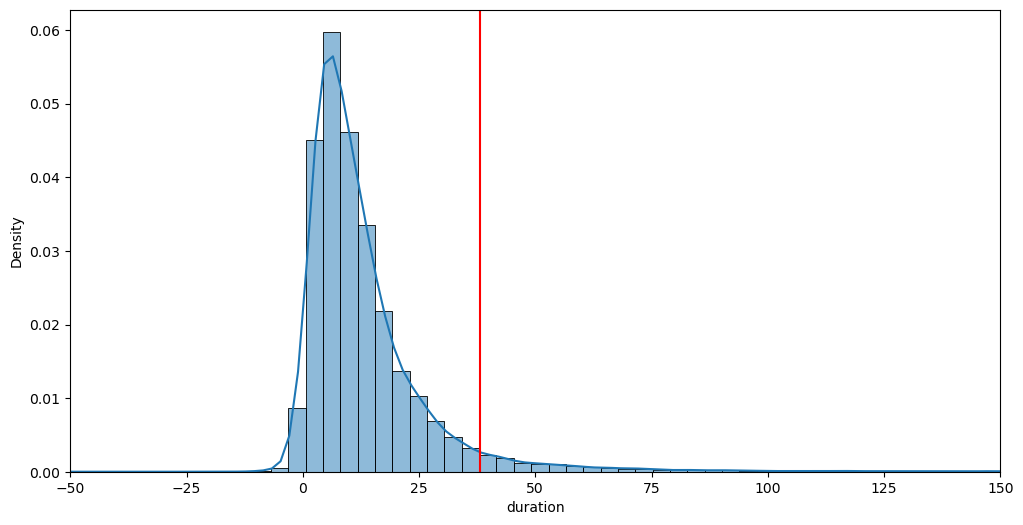

In [40]:
# positive means car duration < transit and vice versa
fig, ax = plot_density(walk_minus_car_duration)
ax.set_xlim(left=-50, right=150)

In [ ]:
# TODO: try the inverse set of plots; for all car trips, how much faster is it than the other modes (and the best)

In [41]:
walk_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    50134.000000
mean        13.849159
std         18.130597
min        -51.665000
25%          5.036667
50%          9.444167
75%         16.567917
95%         38.075750
max        321.598333
Name: duration, dtype: float64

duration difference takeaways

- the distributions for duration difference between mode and car are remarkably similar, with 95 percnetiles around 40-60
- none of these modes can beat out car (and it doesn't even seem close--the amount of trips in each mode where this mode is faster is like 1% for each), so there are some other factors other than duration that drive these people to use these modes
    - this could be due to selection bias -- people who use these modes are "enthusiasts," so a smaller percentile may be needed to account for this

further analysis
- could try a duration percentage analysis as well to standardize duration magnitudes

### distance analysis

In [42]:
# overall

In [43]:
# summary statistics
df["distance"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    451974.000000
mean          6.265382
std           8.274941
min           0.010238
25%           1.180789
50%           3.232732
75%           8.103433
95%          22.148011
max          99.978130
Name: distance, dtype: float64

(0.0, 50.0)

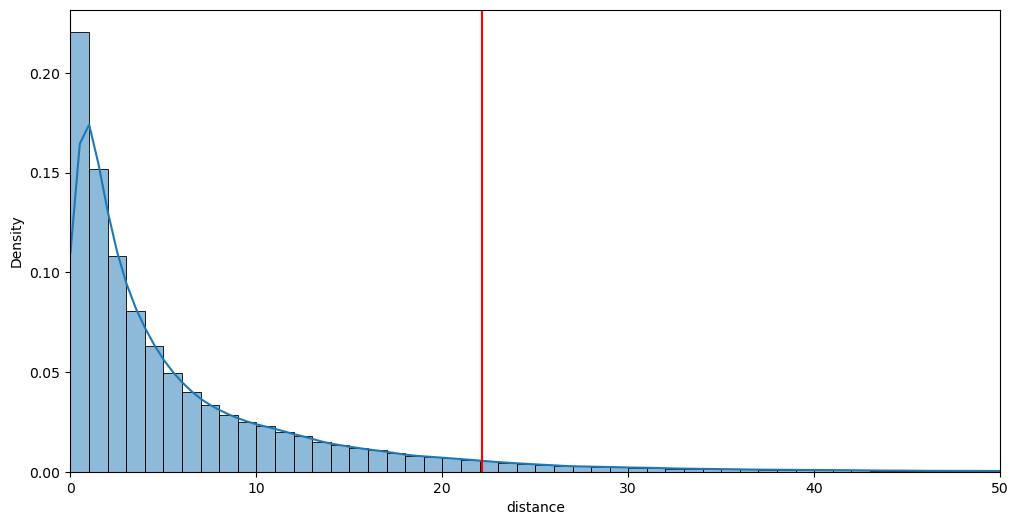

In [44]:
# distribution
fig, ax = plot_density(df["distance"])
ax.set_xlim(left=0, right=50) # max is 99, cut off about half

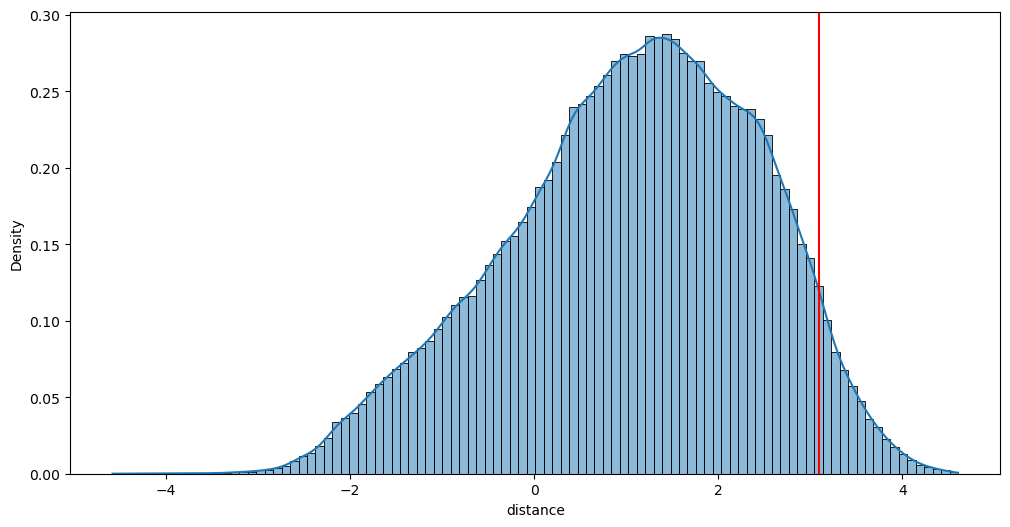

In [45]:
# log distance distribution
# compared with the overall distribution, we see more resolution in the shorter distance trips, which make up a significant portion of all trips
fig, ax = plot_density(np.log(df["distance"]))

In [46]:
# segmented by mode

In [47]:
show_summaries(df, key="distance")

,Car,Bike/Scooter,Walk,Transit
count,377333.000000,7705.000000,50134.000000,11279.000000
mean,7.070595,3.233572,0.698849,6.968255
std,8.618728,4.219710,1.239752,7.469740
min,0.024010,0.057926,0.010238,0.025480
25%,1.678135,0.831384,0.213500,2.151295
50%,3.973360,1.853217,0.397094,4.418200
75%,9.262450,4.052120,0.760542,8.841020
95%,23.540784,10.535152,2.040692,22.071148
max,99.978130,80.358668,55.865006,70.046313


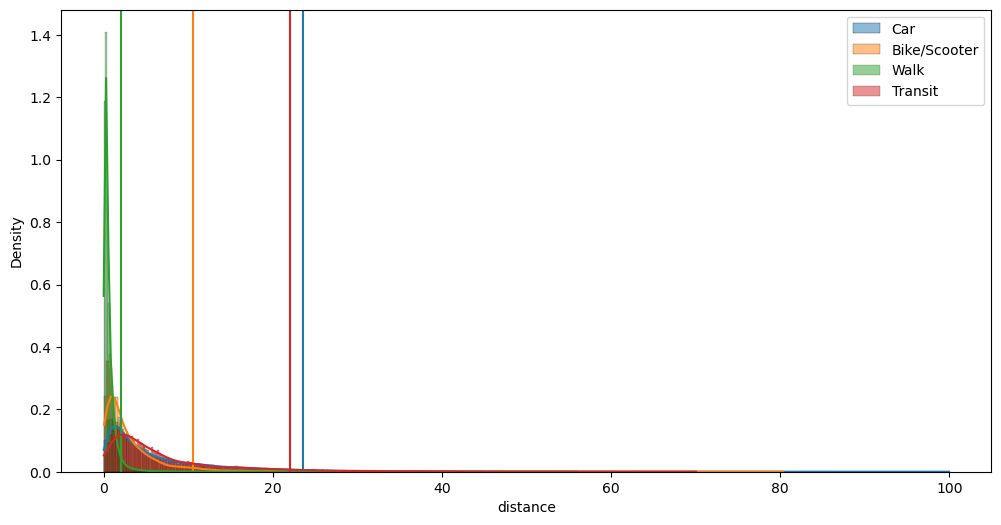

In [48]:
# raw distance distribution (miles)
fig, ax = plot_mode_density(df, key="distance") # this is meaningless
plt.legend()

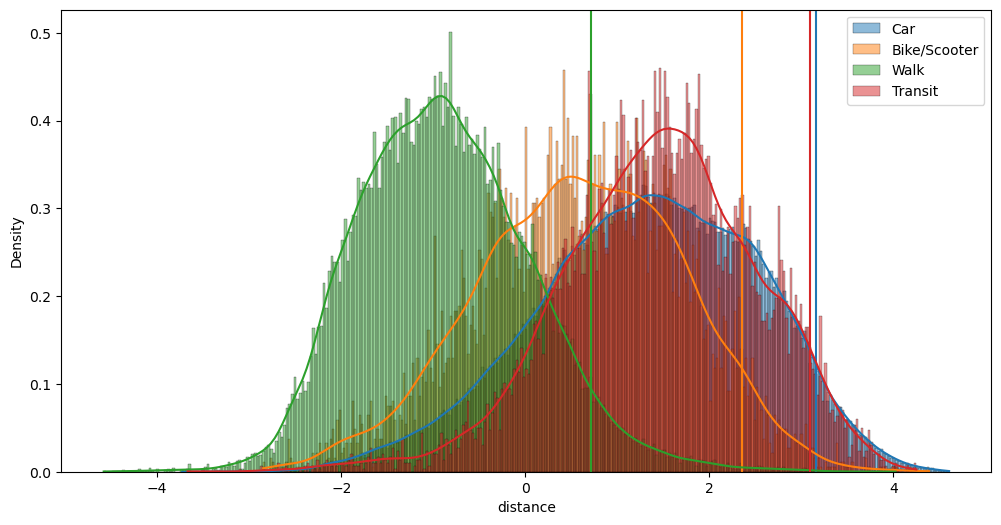

In [49]:
# log distance distribution
fig, ax = plot_mode_density(df, key="distance", function=np.log)
plt.legend()

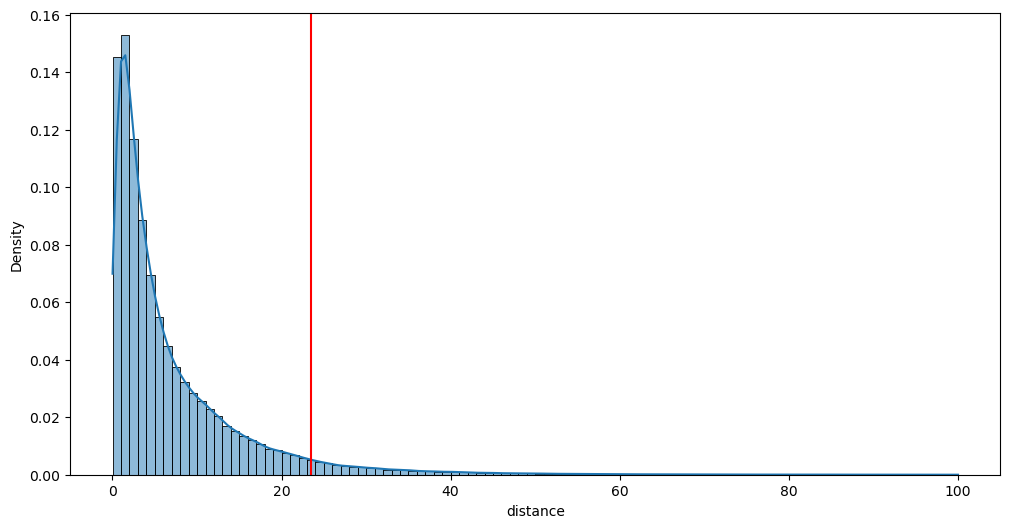

In [96]:
# car distance distribution
fig, ax = plot_density(df[df["mode"] == "Car"]["distance"])

(0.0, 35.0)

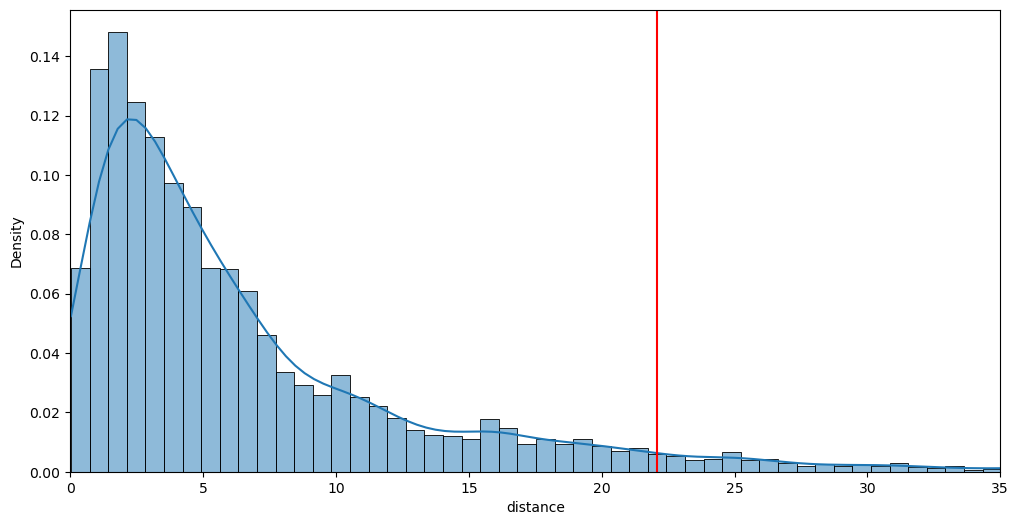

In [110]:

fig, ax = plot_density(df[df["mode"] == "Transit"]["distance"])
ax.set_xlim(left=0, right=35)

(0.0, 4.0)

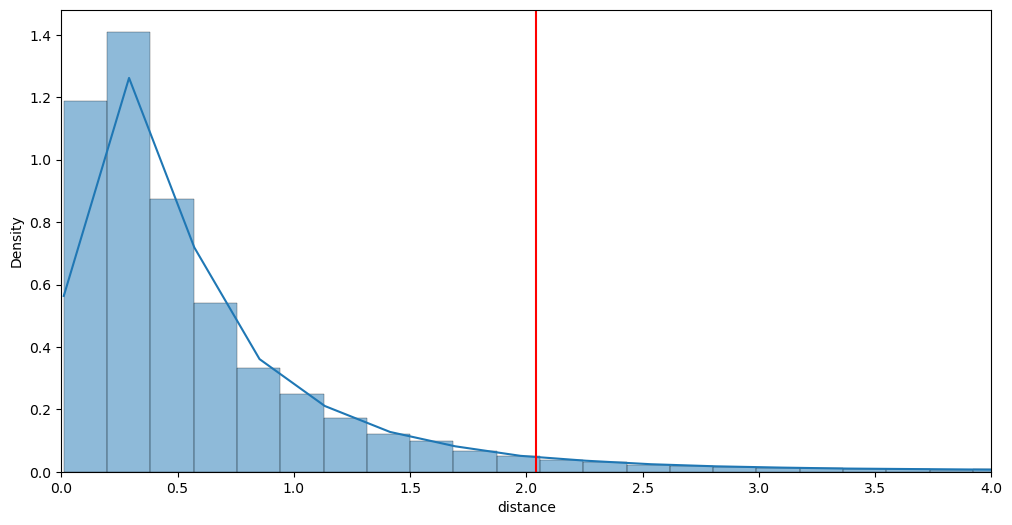

In [104]:

fig, ax = plot_density(df[df["mode"] == "Walk"]["distance"], bins=300)
ax.set_xlim(left=0, right=4)

(0.0, 20.0)

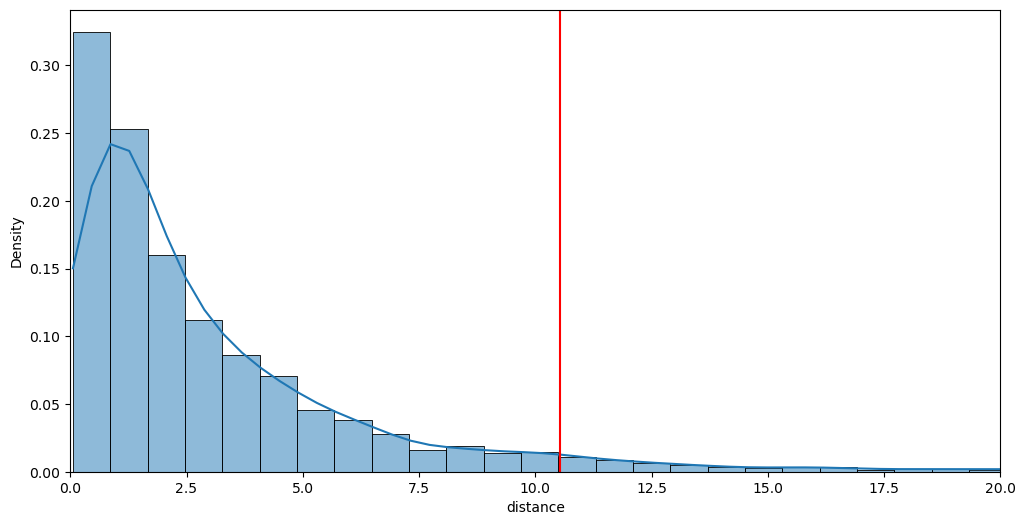

In [107]:
fig, ax = plot_density(df[df["mode"] == "Bike/Scooter"]["distance"])
ax.set_xlim(left=0, right=20)

distance takeaways

- honestly pretty straight forward, not anything surprising
- more continuous than duration, has a continuous decline from 0 distance trips, very much right skewed
    - people prefer shorter distance trips
- car and transit distance distributions are relatively similar -- transit & car riders have relatively similar sensitivies to distance
- walk trips are generally about 1 mile or less
- bike/scooter trips are a middle ground between car/transit and walk

further analysis
- we could do a distance vs car analysis but this probably wouldn't show much--difference between walking around a square and cutting through the middle
- maybe distance in certain areas? like cbd vs suburban or something


### season

(i don't think we can get weather)

In [50]:
df["month"] = df["travel_date"].str[5:7]

In [51]:
def map_to_season(month):
    # can change to a more granular definition
    match month:
        case '12' | '01' | '02':
            return "winter"
        case '03' | '04' | '05':
            return "spring"
        case '06' | '07' | '08':
            return "summer"
        case _:
            return "autumn"

In [52]:
df["season"] = df["month"].apply(map_to_season)
df["season"] = df["month"].apply(map_to_season)

<Axes: xlabel='season', ylabel='count'>

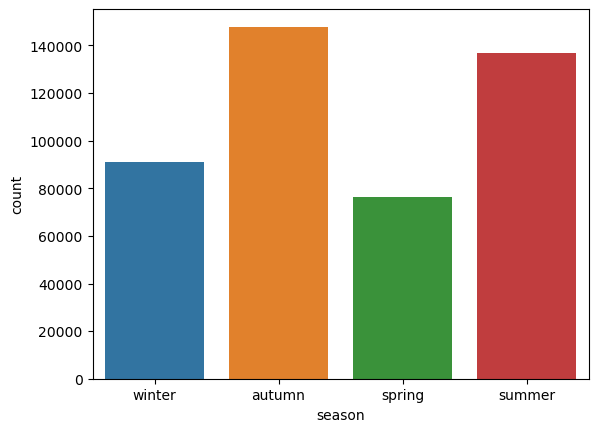

In [53]:
# distribution of season
# WARNING: this could be biased due to the timespan of the data collection -- some season may have been cut short
sns.countplot(x="season", data=df)

In [54]:
# season distribution by mode

In [55]:
def plot_mode_barplot_pct_total(df: pd.DataFrame, key: str, mode:str, func=lambda x: x, figsize=(7, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=df[key].value_counts().sort_index().index, y=func(df[df["mode"] == mode][key].value_counts().sort_index()), ax=ax)
    return fig, ax

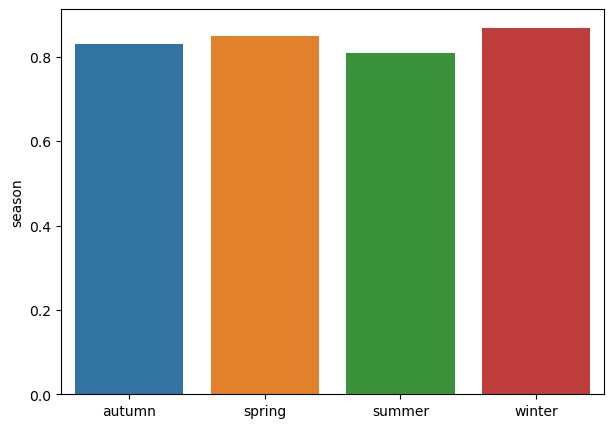

In [56]:
# car seasons
# little variation in car trip % between seasons aside from a slight dip in the summer and slight bump in winter
# thsi represents the % of trips in each season that were by car
fig, ax = plot_mode_barplot_pct_total(df, "season", "Car", lambda x: x / df["season"].value_counts())

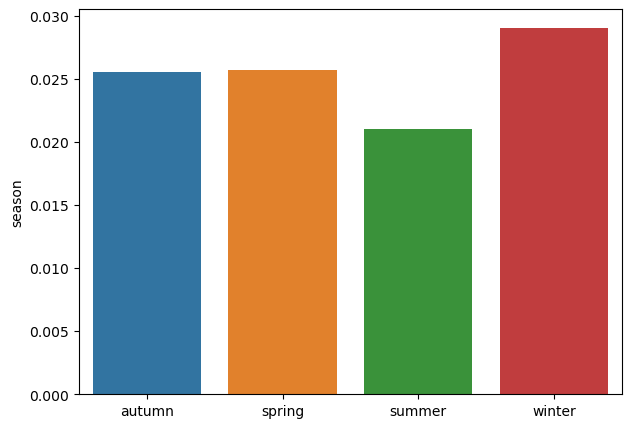

In [57]:
# transit seasons
# significant summer dip & somewhat significant winter bump (possibly due to unsafe conditions otherwise?)
fig, ax = plot_mode_barplot_pct_total(df, "season", "Transit", lambda x: x / df["season"].value_counts())

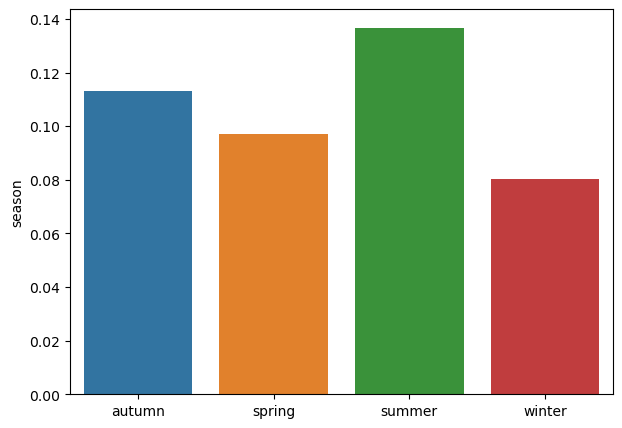

In [58]:
# walk seasons
# significant summer bump & significant winter dip
fig, ax = plot_mode_barplot_pct_total(df, "season", "Walk", lambda x: x / df["season"].value_counts())

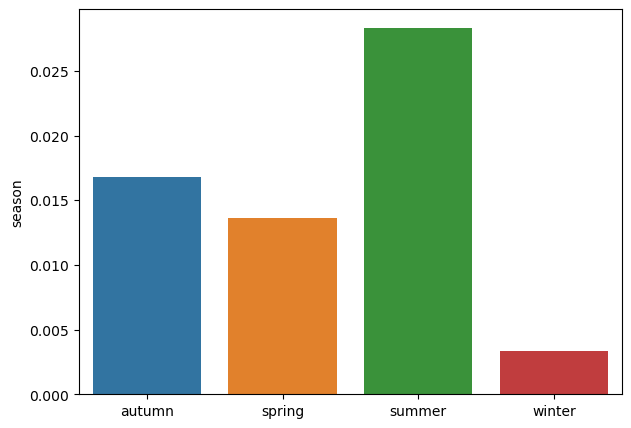

In [59]:
# bike season
# very significant summer bump & very significant winter dip
# basically walk but more extreme variation
fig, ax = plot_mode_barplot_pct_total(df, "season", "Bike/Scooter", lambda x: x / df["season"].value_counts())

In [111]:
0.003/(0.003+0.017+0.013+0.028)

0.04918032786885246

In [ ]:
# TODO: do all 12 months
    # season granualrity is not that much
    # try temperature

takeaways

- seasons do seem to play a large part in the relative proportions of mode trips for non-driving modes
    - comparing relative proportions in distance should be able to handle the sampling timing bias
    - this effect is very pronounced for walking and biking

future analysis
- how do we apply a 95% rule for categorical variables? -- probably need an alternative feasibility indicator
    - could just cut out extreme dips -- e.g., people don't bike in winter
- more granular season definitions
- include weather/ temperature (continuous data) / wind speed / other climate data somehow
    - could just extract average temperatures of the area by day and merge

### daylight hours - yes or no

In [60]:
def plot_multi_barplot(df: pd.DataFrame, x: str, y: str, figsize=(7, 5), order=None):
    # plot normalized bar plot of the values in each mode side by side
    fig, ax = plt.subplots(figsize=figsize)
    if y == "mode": 
        df = df[df["mode"].isin(valid_modes)]
    (df
     .groupby(y)[x]
     .value_counts(normalize=True)
     .mul(100)
     .rename("percent")
     .reset_index()
     .pipe((sns.barplot, "data"), x=x, y="percent", hue=y, ax=ax, order=order)
    )
    
    return fig, ax

In [61]:
df["start_hour"] = df["depart_time"].str[:2]
df["end_hour"] = df["arrive_time"].str[:2]

In [62]:
# define daylight trips to start after 6 AM & end before 6 PM
# currently can't easily account for changes of this with dst/time of year
df["during_daylight"] = np.where((df["start_hour"].astype(int) >= 6) & (df["end_hour"].astype(int) <= 18), 1, 0)

<Axes: xlabel='during_daylight', ylabel='count'>

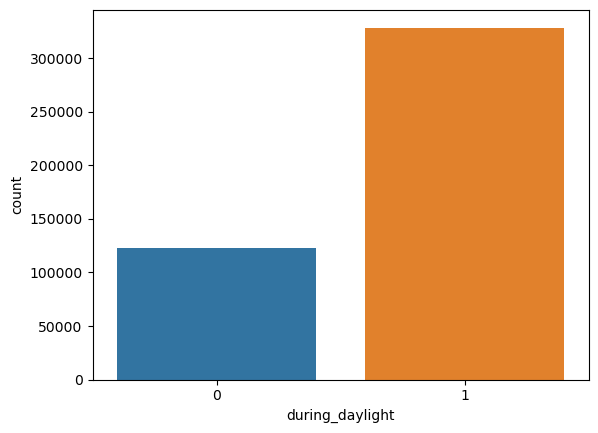

In [63]:
# distribution of trips w.r.t occurring wthin daylight hours
# majority are within daylight hours
# this doesn't have the problem as with seasons as daylight occurs on a daily basis, which the survye likely captures
sns.countplot(x="during_daylight", data=df)

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='during_daylight', ylabel='percent'>)

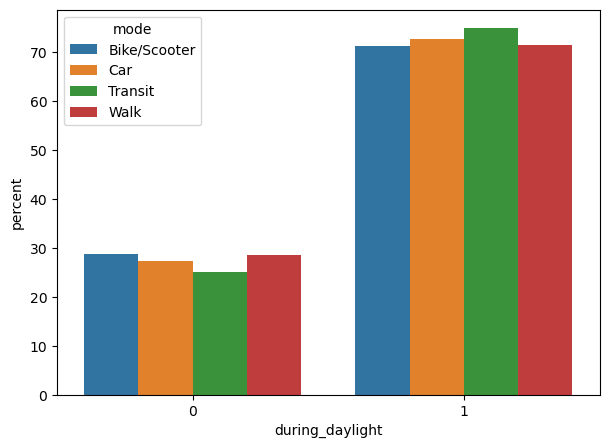

In [64]:
# bar plot of the % of trips in a given mode that occur during/not during daylight side by side for all modes
# inexplicably, there are more walk/biking trips at nighttime
plot_multi_barplot(df, "during_daylight", "mode")

In [65]:
# try another metric -- daylight to nighttime ratio of trips

In [66]:
print("Car daylight to nighttime trip ratio")
print(df[df["mode"] == "Car"]["during_daylight"].value_counts().sort_index()[1] / df[df["mode"] == "Car"]["during_daylight"].value_counts().sort_index()[0])
print()

print("Transit daylight to nighttime trip ratio")
print(df[df["mode"] == "Transit"]["during_daylight"].value_counts().sort_index()[1] / df[df["mode"] == "Transit"]["during_daylight"].value_counts().sort_index()[0])
print()

print("Walk daylight to nighttime trip ratio")
print(df[df["mode"] == "Walk"]["during_daylight"].value_counts().sort_index()[1] / df[df["mode"] == "Walk"]["during_daylight"].value_counts().sort_index()[0])
print()

print("Bike daylight to nighttime trip ratio")
print(df[df["mode"] == "Bike/Scooter"]["during_daylight"].value_counts().sort_index()[1] / df[df["mode"] == "Bike/Scooter"]["during_daylight"].value_counts().sort_index()[0])
print()

Car daylight to nighttime trip ratio
2.6715187841164507

Transit daylight to nighttime trip ratio
3.0010642071656615

Walk daylight to nighttime trip ratio
2.50906418422342

Bike daylight to nighttime trip ratio
2.4754172304916553



takeaways

- probably don't use trip occurs at daytime as indicator
    - walk/bike trips inexplicably occur more often at night

future analysis

- figure out why this pattern is occurring
- alternative metrics?
- dynamic daytime detemrination -- dst and changes over the year

### number of passengers

In [67]:
# overall analysis

In [68]:
# parsing into integer summary statistics
df[df["num_travelers"] != "Missing"]["num_travelers"].astype(int).describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    449976.000000
mean          1.813890
std           1.161894
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
95%           4.000000
max          11.000000
Name: num_travelers, dtype: float64

In [69]:
df["num_travelers_numeric"] = np.where(df["num_travelers"] == "Missing", -1, df["num_travelers"])
df["num_travelers_numeric"] = df["num_travelers_numeric"].astype(int)

<Axes: xlabel='num_travelers_numeric', ylabel='count'>

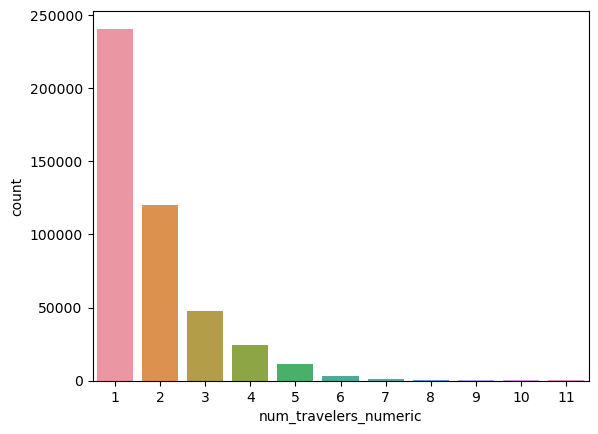

In [70]:
sns.countplot(x="num_travelers_numeric", data=df[df["num_travelers"] != "Missing"])

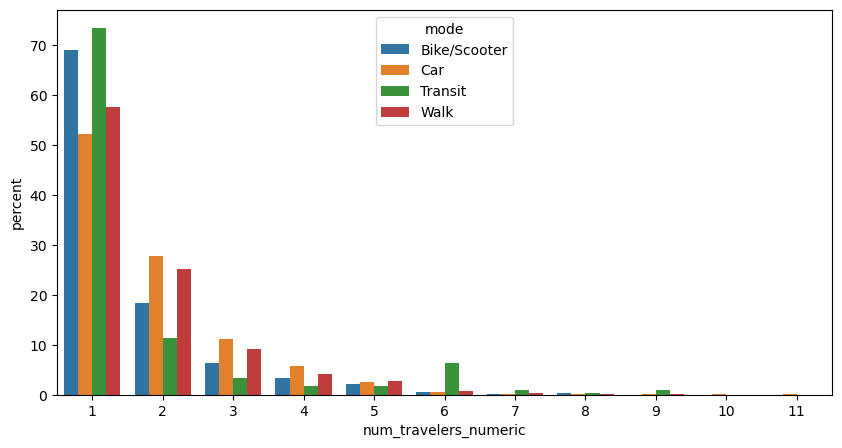

In [71]:
# side-by-side bar plot of the percentage of trips in each mode that have x travelers
# it seems car and walking are the dominant multi-traveler modes
# bike/scooter and transit are generally left-heavier, except for a seemingly random transit peak at 6 travelers
# TODO: try stacked bar chart with mode share (a la season)
fig, ax = plot_multi_barplot(df[df["num_travelers"] != "Missing"], "num_travelers_numeric", "mode", figsize=(10, 5))

In [72]:
# summary statistics of the number of travelers for eahc mode
show_summaries(df[df["num_travelers"] != "Missing"], key="num_travelers_numeric")

,Car,Bike/Scooter,Walk,Transit
count,376737.000000,7695.000000,50019.00000,11232.000000
mean,1.816418,1.539311,1.73564,1.761663
std,1.117541,1.025909,1.13261,1.647639
min,1.000000,1.000000,1.00000,1.000000
25%,1.000000,1.000000,1.00000,1.000000
50%,1.000000,1.000000,1.00000,1.000000
75%,2.000000,2.000000,2.00000,2.000000
95%,4.000000,4.000000,4.00000,6.000000
max,11.000000,8.000000,9.00000,9.000000


takeaways

- transit/biking are modes generally associated with less travelers while walking/driving are hte opposite
    - there are deviations from this trend -- e.g., the dominance of transit from 6-9 travelers (college students? or groups of people going somewhere without cars)

future analysis
- 95% rule probably won't work here -- it's not really reasonable to assume anybody with 4 travelers can just ride via bike/scooter
    - percentiles aren't also necessarily the best here -- data is ordinal, not continuous; need more robust metric for number of people
- possibly go into more detail with number of children/non-household members as well

### traveler details

In [73]:
# traveler ability to drive

In [74]:
df["can_drive"].value_counts()

Yes, drives           382305
No, does not drive     54309
Missing                15360
Name: can_drive, dtype: int64

<Axes: xlabel='can_drive', ylabel='count'>

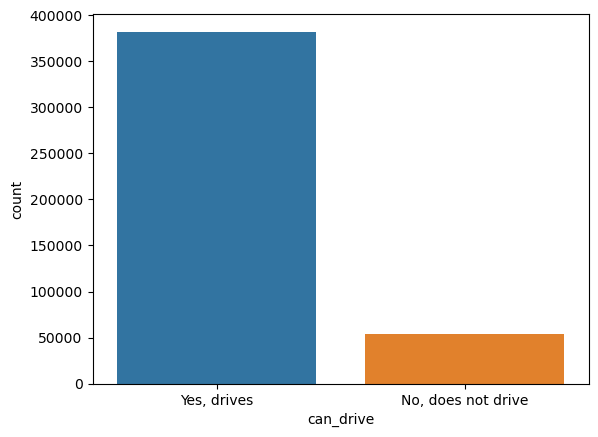

In [75]:
# bar plot of can drive vs can't drive
# most people can drive
# does htis include car ownership or just license?
sns.countplot(x="can_drive", data=df[df["can_drive"] != "Missing"])

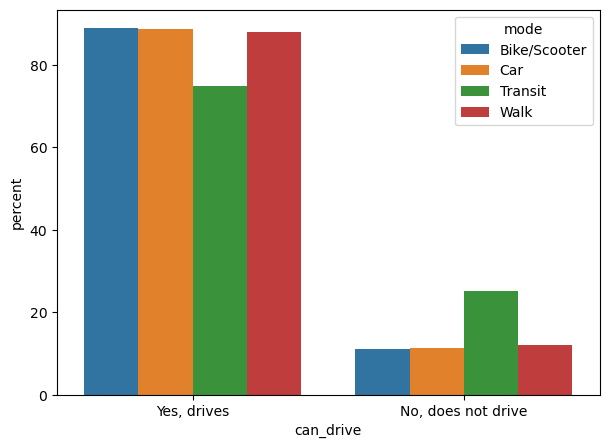

In [76]:
# side by side bar plot of the % of epople in each mode who can drive/can't drive
# relatively uniform aside from transit -- people who can drive have a lesser tendency to not use transit & vice versa
# transit may directly substitute car trips while other modes simply complement them
fig, ax = plot_multi_barplot(df[df["can_drive"] != "Missing"], "can_drive", "mode")

In [77]:
# age analysis

In [78]:
df["age"].value_counts()

35-44          58536
25-34          54345
55-64          47780
45-54          43498
35 to 44       34806
25 to 34       33183
65-74          30543
5-15           27564
55 to 64       20739
45 to 54       20679
Under 5        20296
65 to 74       16596
18-24          12359
5 to 15         8991
18 to 24        7637
75 or older     6890
75 to 84        3466
16-17           3199
16 to 17         672
85 or older      195
Name: age, dtype: int64

In [79]:
# merge the two different labeling schemes
df["age_cleaned"] = df["age"].apply(lambda x: '-'.join(x.split(" to ")))
df["age_cleaned"] = np.where(df["age_cleaned"] == "5-15", "05-15", df["age_cleaned"])
df["age_cleaned"] = np.where(df["age_cleaned"] == "Under 5", "00-05", df["age_cleaned"])

<Axes: xlabel='age_cleaned', ylabel='count'>

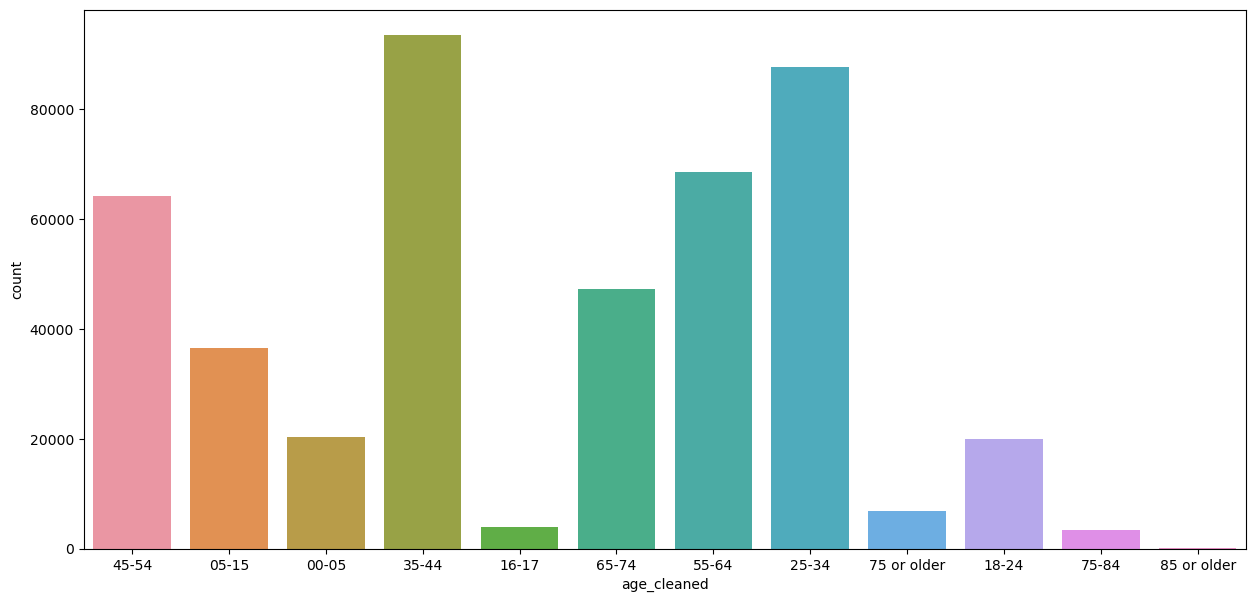

In [80]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.countplot(x="age_cleaned", data=df, ax=ax)

(<Figure size 1500x700 with 1 Axes>,
 <Axes: xlabel='age_cleaned', ylabel='percent'>)

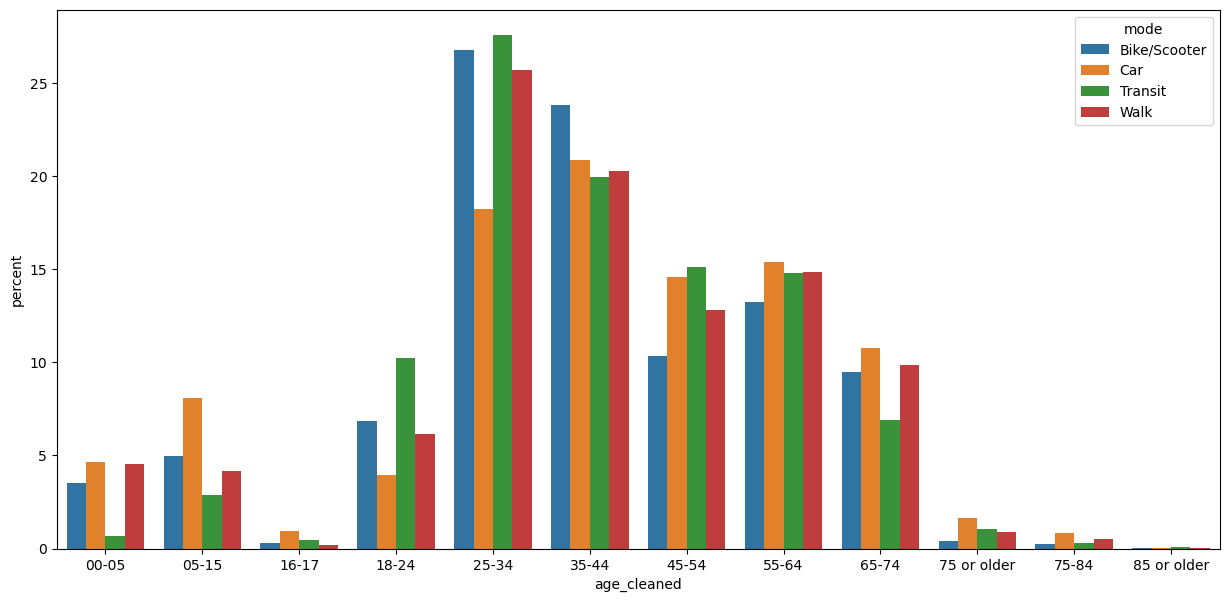

In [81]:
# side by side bar plot of the % of trips of each mode that were made by certain age groups
# generally, car usage is less dominant from 18-44, after which car becomes more dominant
# transit usage decays from a peak in 25-34
plot_multi_barplot(df, "age_cleaned", y="mode", figsize=(15, 7), order=df["age_cleaned"].value_counts().sort_index().index)

In [ ]:
# age - can't really rule out anything
    # maybe old people can't bike
# one record for each person id -- both

In [82]:
# disability

In [83]:
df["disability"].value_counts()

No                       367980
Missing: Skip logic       45407
Missing                   16171
Yes                       14387
Prefer not to answer       6593
Missing: Non-response      1436
Name: disability, dtype: int64

In [84]:
# clean all missing things into one NA value
df["disability_cleaned"] = np.where(df["disability"].isin(["No", "Yes"]), df["disability"], "NA")

In [85]:
df["disability_cleaned"].value_counts()

No     367980
NA      69607
Yes     14387
Name: disability_cleaned, dtype: int64

<Axes: xlabel='disability_cleaned', ylabel='count'>

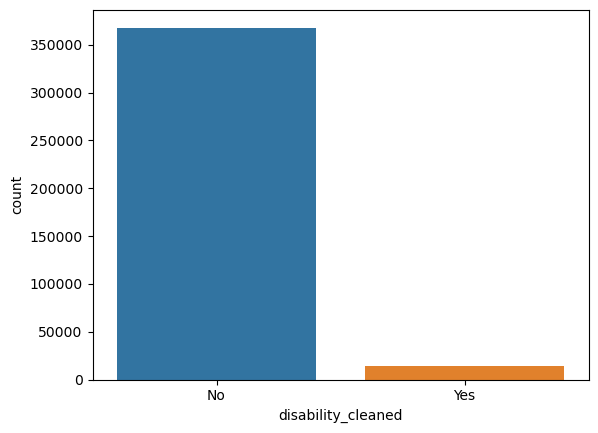

In [86]:
sns.countplot(x="disability_cleaned", data=df[df["disability_cleaned"] != "NA"])

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='disability_cleaned', ylabel='percent'>)

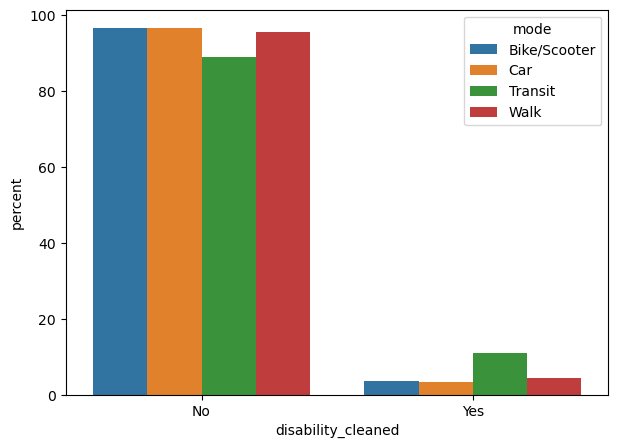

In [87]:
# side by side bar plot of the % of trips via each mode who do/do not have disabilities
# similar trend to those without cars -- those with disabilities tend to travel via transit, with everything else uniform
plot_multi_barplot(df[df["disability_cleaned"] != "NA"], "disability_cleaned", "mode")

takeaways
- those who cannot drive/are disabled have a greater likelihood of choosing transit, although not very significantly
    - there is likely some overlap between these groups
    - with these variables, all other modes are uniform -- there is something unique about transit in catering to these people
- the relationship between age & mode choice/preferences are complex, but there definitely do seem to be patterns

future analysis
- possibly explore more personal variables
- can explore the combination of personal variables with other ones
    - e.g., people with disabilities that have multiple people in their household/travel with multiple people often

In [ ]:
# TODO: summary of all the varaibles + the feasibility indicator
# TODO: do something with % of cars that can shift given each indicator

In [112]:
# all feasibility indicators have to be met
# walk comes later

,trip_id,duration_seconds,distance_meters,weight,geometry
0,[1811206201001],21312.0,26137.5,21312.0,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
1,[1811206201002],21312.0,26137.5,21312.0,"LINESTRING (-92.91716 44.51007, -92.91715 44.5..."
2,[1811206203001],10848.5,15066.6,10848.5,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
3,[1811206203002],10848.5,15066.6,10848.5,"LINESTRING (-92.88609 44.73583, -92.88572 44.7..."
4,[1811206204001],10290.3,14292.2,10290.3,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
...,...,...,...,...,...
458645,[2200279003003],2751.3,3821.7,2751.3,"LINESTRING (-93.14578 44.91527, -93.14603 44.9..."
458646,[2200279101001],4248.0,5894.8,4248.0,"LINESTRING (-93.38229 45.04008, -93.38164 45.0..."
458647,[2200279101002],4248.0,5894.8,4248.0,"LINESTRING (-93.35434 45.07169, -93.35359 45.0..."
458648,[2200279102001],3210.6,4453.7,3210.6,"LINESTRING (-93.38229 45.04008, -93.38289 45.0..."
